# 高光谱数据预处理主流程：参考仓库对齐版 / Reference-aligned workflow

本 Notebook 对齐参考 `Highspectrum.ipynb` 的“数据读取 → 伪彩色与标签统计 →
波段关系 → PCA/LDA → patch → 模型输入 → 结果导出”展示链，同时继续执行本项目
更严格的冻结划分和**仅训练集拟合**约束。它会复用已有预处理状态，不会重新划分样本，
也不会用验证集或测试集拟合标准化、PCA、LDA。

最终产物包括 `model_ready_dataset.npz`，以及可直接放入实验报告的 PNG/CSV 图表。


## 与参考 `Highspectrum.ipynb` 的流程对应关系

| 参考流程 | 本 Notebook 对应内容 | 口径说明 |
|---|---|---|
| PaviaU MAT 读取与尺寸检查 | 步骤 2 | 路径来自 YAML，禁止硬编码 |
| 伪彩色影像、类别数量、Ground Truth 与叠加图 | 参考对齐展示 A | 使用固定色表并导出报告图 |
| 波段相关性分析 | 统计 2C | 只用训练中心像元，避免查看测试光谱统计 |
| PCA/LDA 特征降维与分量图 | 步骤 3–4、统计 4C | 加载仅由训练集拟合的冻结状态 |
| patch 构造与训练/测试划分 | 步骤 5–7 | `25×25` patch 按需提取，不复制海量邻域 |
| 后续分类与分类图 | `HybridSN模型结构学习.ipynb` | 本 Notebook 只准备模型输入，不假装输出分类结果 |

参考本中的 Gabor/LBP/GLCM 与传统分类器属于后续特征优化路线，本阶段不混入
HybridSN baseline；未来会在同一冻结 split 上作为独立实验进行对比。


In [1]:
# 整体作用：准备路径、绘图、数值计算和 PyTorch 环境，并只导入底层数据核心。
# Notebook 不再依赖 scripts/运行数据预处理.py 或外部可视化封装。
from pathlib import Path
import math
import sys

import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    matplotlib.use('Agg')  # 无界面验收 / Headless verification
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import torch
import yaml

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 从当前目录向上寻找 pyproject.toml，保证从 notebooks/ 或项目根目录启动都能定位。
def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise FileNotFoundError('Cannot locate 实验交付/pyproject.toml')

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 只复用 src/ 中经过测试的底层算法；七步组织、检查和绘图均在本 Notebook 展开。
from src.datasets.高光谱预处理 import (
    HSIPreprocessingPipeline,
    PreprocessingConfig,
    load_hsi_data,
)

SPLIT_NAMES = ('train', 'validation', 'test')
SPLIT_LABELS = ('训练 / Train', '验证 / Validation', '测试 / Test')
SPLIT_COLORS = ('#4472C4', '#ED7D31', '#A5A5A5')
PAVIA_CLASS_NAMES_ZH = (
    '沥青路面', '草地', '砾石', '树木', '涂漆金属板',
    '裸土', '沥青材料', '自锁砖', '阴影',
)
CLASS_COLORS = tuple(plt.get_cmap('tab10')(index) for index in range(9))

def class_title(class_id: int, english: str) -> str:
    chinese = PAVIA_CLASS_NAMES_ZH[class_id - 1]
    return f'{class_id}. {chinese} / {english}'

print(f'项目根目录 / Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA 可用 / CUDA available: {torch.cuda.is_available()}')


项目根目录 / Project root: G:\高光谱智能图像解译\实验交付
PyTorch: 2.12.1+cu130
CUDA 可用 / CUDA available: True


## 步骤 1：加载配置 / Step 1: Load configuration

- **目的 / Purpose：** 固定数据协议、预处理路线与 DataLoader 参数。
- **输入 / Input：** HybridSN 论文复现基线配置 `HybridSN_Pavia论文复现基线.yaml`。
- **输出 / Output：** `WorkflowSettings`。
- **验收 / Acceptance：** seed=1442，路线名和冻结状态目录唯一。


In [2]:
# 整体作用：读取 HybridSN 论文基线 YAML，固定数据处理路线和产物目录。
# 本代码框直接展示解析过程，不再调用 scripts/ 中的包装函数。

# 1. 读取 YAML 并转换为经过类型校验的 PreprocessingConfig。
CONFIG_PATH = PROJECT_ROOT / 'configs/模型训练/HybridSN_Pavia论文复现基线.yaml'
config_values = yaml.safe_load(CONFIG_PATH.read_text(encoding='utf-8'))
assert isinstance(config_values, dict)
config = PreprocessingConfig.from_mapping(config_values)

# 2. 路线名唯一决定冻结预处理状态和模型就绪数据所在目录。
state_dir = (
    PROJECT_ROOT / 'data/processed' / config.dataset_name / config.route_name()
)

# 3. DataLoader 参数优先读取 dataloader 段；本基线没有该段时使用固定默认值。
loader_values = config_values.get('dataloader', {})
batch_size = int(loader_values.get('batch_size', 256))
loader_seed = int(loader_values.get('loader_seed', 1442))
num_workers = int(loader_values.get('num_workers', 0))
pin_memory = bool(loader_values.get('pin_memory', True)) and torch.cuda.is_available()

assert batch_size > 0
assert num_workers >= 0
print({
    'route': config.route_name(),
    'state_dir': str(state_dir),
    'batch_size': batch_size,
    'loader_seed': loader_seed,
})


{'route': 'paper30__seed1442__standard_pca15_patch25', 'state_dir': 'G:\\高光谱智能图像解译\\实验交付\\data\\processed\\pavia_university\\paper30__seed1442__standard_pca15_patch25', 'batch_size': 256, 'loader_seed': 1442}


## 步骤 2：读取原始数据与固定划分 / Step 2: Load raw data and frozen split

- **目的 / Purpose：** 建立光谱、二维坐标、标签与 split 身份的对应关系。
- **输入 / Input：** 只读 `.mat` 数据和已冻结 `.npz/.json` 划分。
- **输出 / Output：** `HSIDataBundle`。
- **验收 / Acceptance：** 42,776 个有标签像元被无重叠地完整覆盖。


In [3]:
# 整体作用：只读加载 Pavia 原始数据与固定划分，并统计标注覆盖情况。

# load_hsi_data 会读取 YAML 指定的 .mat 和既有 split 文件，不会生成新划分。
data = load_hsi_data(PROJECT_ROOT, config)

# 三个 split 的索引必须完整覆盖全部有标签样本。
assert sum(len(v) for v in data.indices_by_split.values()) == len(data.labels)
split_counts = {name: int(data.indices_by_split[name].size) for name in SPLIT_NAMES}

# 标签 0 是背景；data.labels 只保存 1–9 类有标签像元。
total_pixels = data.label_map.size
labeled_pixels = len(data.labels)
background_pixels = total_pixels - labeled_pixels
print(f'总像元 / Total pixels: {total_pixels:,}')
print(f'有标签像元 / Labeled pixels: {labeled_pixels:,} ({labeled_pixels / total_pixels:.2%})')
print(f'背景或未标注 / Background or unlabeled: {background_pixels:,} ({background_pixels / total_pixels:.2%})')
print(f"Split: {split_counts}")


总像元 / Total pixels: 207,400
有标签像元 / Labeled pixels: 42,776 (20.62%)
背景或未标注 / Background or unlabeled: 164,624 (79.38%)
Split: {'train': 12832, 'validation': 0, 'test': 29944}


### 参考对齐展示 A：伪彩色、类别数量、标签图与叠加图

对应参考 `Highspectrum.ipynb` 的数据可视化部分。伪彩色使用第 70、28、21
波段（Python 下标 69、27、20），每个通道采用 2%–98% 分位拉伸。
类别表保留背景类 0，便于核对 `610×340=207,400` 个像元的组成。


,类别编号,中文类别,English class,像元数,占全图比例
0,0,背景/未标注,Background / unlabeled,164624,79.38%
1,1,沥青路面,Asphalt,6631,3.20%
2,2,草地,Meadows,18649,8.99%
3,3,砾石,Gravel,2099,1.01%
4,4,树木,Trees,3064,1.48%
5,5,涂漆金属板,Painted metal sheets,1345,0.65%
6,6,裸土,Bare Soil,5029,2.42%
7,7,沥青材料,Bitumen,1330,0.64%
8,8,自锁砖,Self-Blocking Bricks,3682,1.78%
9,9,阴影,Shadows,947,0.46%


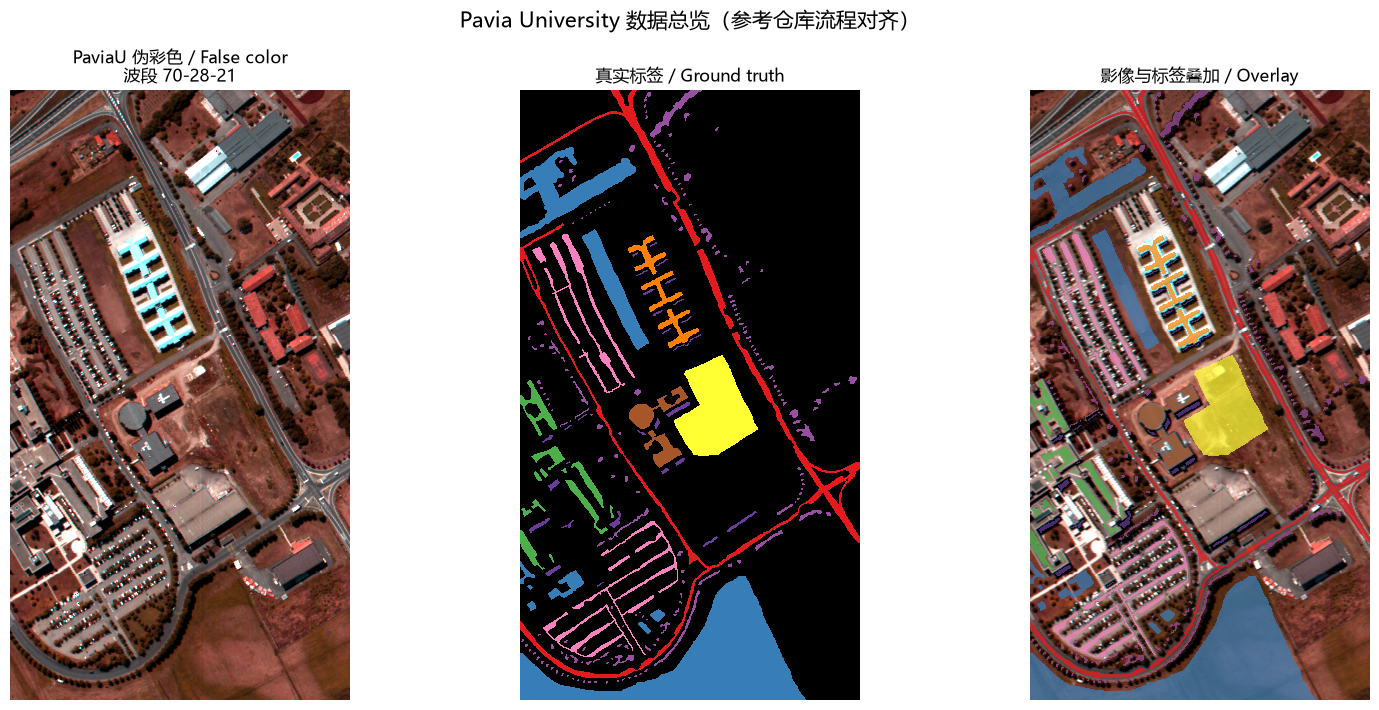

报告素材目录 / Report assets: G:\高光谱智能图像解译\实验交付\results\notebook_outputs\reference_aligned\data_preprocessing


In [4]:
# 参考流程所需的报告级数据总览；不拟合任何统计模型。
import pandas as pd
from IPython.display import display

REPORT_ASSET_DIR = PROJECT_ROOT / 'results/notebook_outputs/reference_aligned/data_preprocessing'
REPORT_ASSET_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_LABEL_COLORS = (
    '#000000', '#E41A1C', '#377EB8', '#4DAF4A', '#984EA3',
    '#FF7F00', '#FFFF33', '#A65628', '#F781BF', '#6A3D9A',
)
reference_label_cmap = ListedColormap(REFERENCE_LABEL_COLORS)

def percentile_stretch(channel: np.ndarray) -> np.ndarray:
    low, high = np.percentile(channel, (2, 98))
    if high <= low:
        return np.zeros_like(channel, dtype=np.float32)
    return np.clip((channel - low) / (high - low), 0, 1).astype(np.float32)

rgb_band_indices = (69, 27, 20)
false_color = np.stack(
    [percentile_stretch(data.cube[:, :, band]) for band in rgb_band_indices],
    axis=-1,
)

pixel_counts = np.bincount(data.label_map.reshape(-1), minlength=10)
class_rows = [{
    '类别编号': 0,
    '中文类别': '背景/未标注',
    'English class': 'Background / unlabeled',
    '像元数': int(pixel_counts[0]),
    '占全图比例': float(pixel_counts[0] / data.label_map.size),
}]
for class_id, english_name in enumerate(data.spec.class_names, start=1):
    class_rows.append({
        '类别编号': class_id,
        '中文类别': PAVIA_CLASS_NAMES_ZH[class_id - 1],
        'English class': english_name,
        '像元数': int(pixel_counts[class_id]),
        '占全图比例': float(pixel_counts[class_id] / data.label_map.size),
    })
class_distribution_table = pd.DataFrame(class_rows)
assert int(class_distribution_table['像元数'].sum()) == data.label_map.size
display(class_distribution_table.style.format({'占全图比例': '{:.2%}'}))

masked_labels = np.ma.masked_where(data.label_map == 0, data.label_map)
overview_figure, axes = plt.subplots(1, 3, figsize=(16, 7.2))
axes[0].imshow(false_color)
axes[0].set_title('PaviaU 伪彩色 / False color\n波段 70-28-21')
axes[1].imshow(data.label_map, cmap=reference_label_cmap, vmin=0, vmax=9, interpolation='nearest')
axes[1].set_title('真实标签 / Ground truth')
axes[2].imshow(false_color)
axes[2].imshow(masked_labels, cmap=reference_label_cmap, vmin=0, vmax=9,
               interpolation='nearest', alpha=0.72)
axes[2].set_title('影像与标签叠加 / Overlay')
for axis in axes:
    axis.axis('off')
overview_figure.suptitle('Pavia University 数据总览（参考仓库流程对齐）', fontsize=15)
overview_figure.tight_layout()
overview_figure.savefig(REPORT_ASSET_DIR / '01_PaviaU数据总览.png', dpi=220, bbox_inches='tight')
class_distribution_table.to_csv(
    REPORT_ASSET_DIR / '01_PaviaU类别数量.csv', index=False, encoding='utf-8-sig'
)
plt.show()
print(f'报告素材目录 / Report assets: {REPORT_ASSET_DIR}')


### 检查 2C：固定划分约束与两协议关系 / Check 2C: Frozen split contract

该检查继承原固定划分 Notebook 中最重要的验收内容：当前协议三组无交集并覆盖全部有标签像元，每个非空 split 含九类；两协议样本身份相同、测试集相同，且 `fair.train ∪ fair.validation = paper30.train`。源文件哈希和同 seed 重建由 `scripts/验证固定划分.py` 与自动测试继续负责。


In [5]:
# 整体作用：验证冻结划分及两套协议的既定关系，防止 split 被意外改变。

# 1. 当前协议内部：无重叠、全覆盖、每个非空 split 覆盖九类。
assigned = np.concatenate([data.indices_by_split[name] for name in SPLIT_NAMES])
expected_classes = np.arange(1, len(data.spec.class_names) + 1)
rows, columns = data.coordinates.T
split_checks = {
    'current_disjoint': np.unique(assigned).size == assigned.size,
    'current_full_coverage': np.array_equal(
        np.sort(assigned), np.arange(data.labels.size)
    ),
    'current_class_coverage': all(
        indices.size == 0
        or np.array_equal(np.unique(data.labels[indices]), expected_classes)
        for indices in data.indices_by_split.values()
    ),
    'coordinate_label_alignment': np.array_equal(
        data.labels, data.label_map[rows, columns]
    ),
}

# 2. 跨协议：paper30 与 fair24_6_70 必须共享样本身份和测试集。
protocol_arrays = {}
for protocol_name in ('paper30', 'fair24_6_70'):
    split_path = (
        PROJECT_ROOT / 'data/splits'
        / f'{config.dataset_name}__{protocol_name}__seed{config.split_seed}.npz'
    )
    assert split_path.is_file(), split_path
    with np.load(split_path, allow_pickle=False) as saved:
        protocol_arrays[protocol_name] = {
            name: saved[name].copy()
            for name in (
                'coordinates', 'labels', 'train_indices',
                'validation_indices', 'test_indices',
            )
        }

paper = protocol_arrays['paper30']
fair = protocol_arrays['fair24_6_70']
split_checks.update({
    'same_sample_identity': (
        np.array_equal(paper['coordinates'], fair['coordinates'])
        and np.array_equal(paper['labels'], fair['labels'])
    ),
    'shared_test_set': np.array_equal(
        paper['test_indices'], fair['test_indices']
    ),
    'fair_train_plus_validation_equals_paper_train': np.array_equal(
        paper['train_indices'],
        np.sort(np.concatenate([fair['train_indices'], fair['validation_indices']])),
    ),
})

assert all(bool(value) for value in split_checks.values())
split_checks


{'current_disjoint': True,
 'current_full_coverage': True,
 'current_class_coverage': True,
 'coordinate_label_alignment': True,
 'same_sample_identity': True,
 'shared_test_set': True,
 'fair_train_plus_validation_equals_paper_train': True}

### 统计 2A：划分数量与空间位置 / Analysis 2A: Split counts and locations

这两幅统计只展示已经冻结的实验设计：总体/逐类样本数以及各 split 中心像元的位置。它们可以包含测试 split，因为没有查看测试光谱或预测结果。


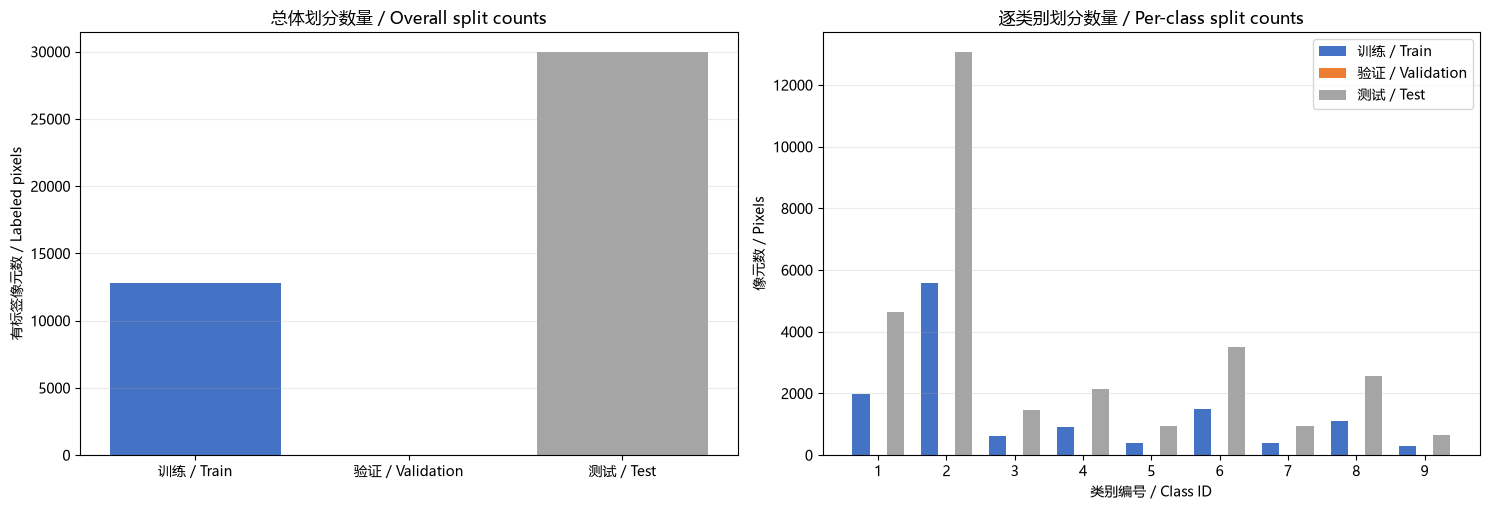

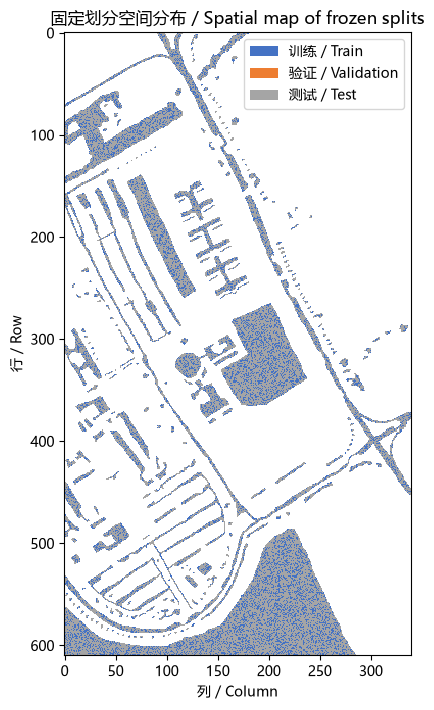

In [6]:
# 整体作用：从样本数量和空间位置两个角度检查固定数据划分。

# 1. 逐类别统计 train/validation/test 样本数。
class_count = len(data.spec.class_names)
counts = np.zeros((class_count, len(SPLIT_NAMES)), dtype=np.int64)
for split_column, split_name in enumerate(SPLIT_NAMES):
    split_labels = data.labels[data.indices_by_split[split_name]]
    for class_id in range(1, class_count + 1):
        counts[class_id - 1, split_column] = np.count_nonzero(
            split_labels == class_id
        )
assert int(counts.sum()) == data.labels.size

# 2. 左图显示总体数量，右图显示逐类别数量。
split_count_figure, axes = plt.subplots(1, 2, figsize=(15, 5.2))
totals = counts.sum(axis=0)
axes[0].bar(SPLIT_LABELS, totals, color=SPLIT_COLORS)
axes[0].set_title('总体划分数量 / Overall split counts')
axes[0].set_ylabel('有标签像元数 / Labeled pixels')
axes[0].grid(axis='y', alpha=0.25)

class_ids = np.arange(1, class_count + 1)
width = 0.25
for offset, (label, color) in enumerate(zip(SPLIT_LABELS, SPLIT_COLORS)):
    axes[1].bar(
        class_ids + (offset - 1) * width, counts[:, offset],
        width=width, label=label, color=color,
    )
axes[1].set_title('逐类别划分数量 / Per-class split counts')
axes[1].set_xlabel('类别编号 / Class ID')
axes[1].set_ylabel('像元数 / Pixels')
axes[1].set_xticks(class_ids)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
split_count_figure.tight_layout()
plt.show()

# 3. 把每个样本所属 split 写回二维坐标，绘制空间分布图。
membership = np.full(data.label_map.shape, np.nan, dtype=np.float32)
for split_id, split_name in enumerate(SPLIT_NAMES):
    indices = data.indices_by_split[split_name]
    rows, columns = data.coordinates[indices].T
    membership[rows, columns] = split_id
split_cmap = ListedColormap(SPLIT_COLORS).with_extremes(bad='white')

split_map_figure, axis = plt.subplots(figsize=(8.5, 7.2))
axis.imshow(
    np.ma.masked_invalid(membership), cmap=split_cmap,
    vmin=-0.5, vmax=2.5, interpolation='nearest',
)
axis.set_title('固定划分空间分布 / Spatial map of frozen splits')
axis.set_xlabel('列 / Column')
axis.set_ylabel('行 / Row')
axis.legend(handles=[
    Patch(facecolor=color, label=label)
    for color, label in zip(SPLIT_COLORS, SPLIT_LABELS)
])
split_map_figure.tight_layout()
plt.show()


### 统计 2B：训练集逐类原始光谱 / Analysis 2B: Train-only class spectra

每个面板显示一个类别的训练光谱均值和 ±1 标准差。横轴是波段编号，不是实际波长；该图不读取验证或测试特征。


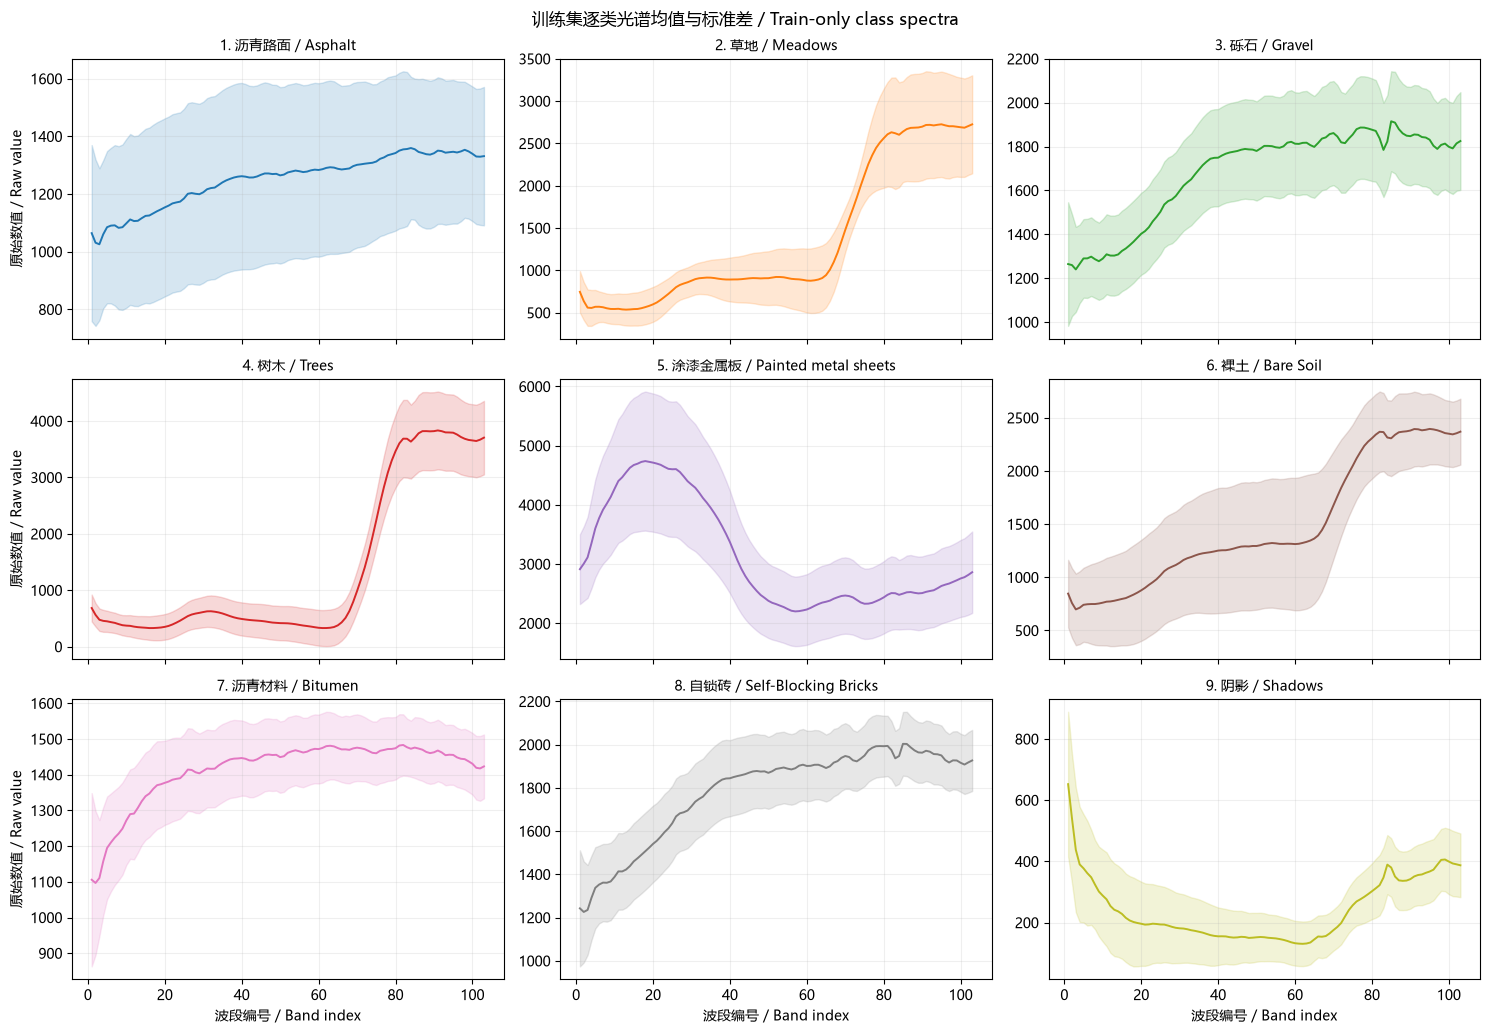

In [7]:
# 整体作用：只用训练样本绘制九类平均光谱，理解类别间的光谱差异。

# 1. 根据训练坐标从原始 103 波段立方体提取光谱。
train_rows, train_columns = data.train_coordinates.T
train_spectra = data.cube[train_rows, train_columns, :].astype(np.float64)
train_labels = data.train_labels
bands = np.arange(1, data.cube.shape[2] + 1)

# 2. 每一类分别绘制均值曲线和 ±1 标准差范围。
spectral_figure, axes = plt.subplots(3, 3, figsize=(15, 10.5), sharex=True)
for class_id, (english, axis) in enumerate(
    zip(data.spec.class_names, axes.reshape(-1)), start=1
):
    values = train_spectra[train_labels == class_id]
    mean = values.mean(axis=0)
    std = values.std(axis=0)
    color = CLASS_COLORS[class_id - 1]
    axis.plot(bands, mean, color=color, linewidth=1.4)
    axis.fill_between(bands, mean - std, mean + std, color=color, alpha=0.18)
    axis.set_title(class_title(class_id, english), fontsize=10)
    axis.grid(alpha=0.2)
for axis in axes[-1, :]:
    axis.set_xlabel('波段编号 / Band index')
for axis in axes[:, 0]:
    axis.set_ylabel('原始数值 / Raw value')
spectral_figure.suptitle('训练集逐类光谱均值与标准差 / Train-only class spectra')
spectral_figure.tight_layout()
plt.show()


### 统计 2C：训练集波段相关性 / Train-only band correlation

对应参考 Notebook 的波段相关性分析。相关矩阵只由 12,832 个训练中心像元计算；
它用于说明相邻波段冗余和降维动机，不参与测试结果解释。


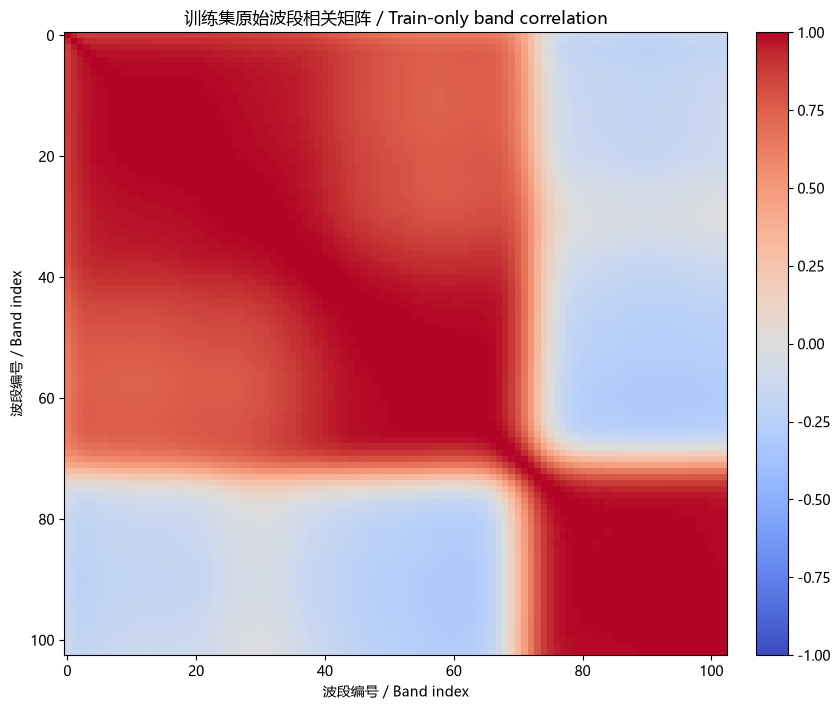

{'mean_absolute_interband_correlation': 0.5887074794777263, 'fraction_abs_correlation_ge_0.95': 0.2630877593755949}


In [8]:
# 只用训练中心像元计算 103 个原始波段之间的 Pearson 相关系数。
band_correlation = np.corrcoef(train_spectra, rowvar=False)
assert band_correlation.shape == (data.cube.shape[-1], data.cube.shape[-1])
assert np.allclose(np.diag(band_correlation), 1.0)

band_correlation_figure, axis = plt.subplots(figsize=(8.5, 7.2))
image = axis.imshow(band_correlation, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
axis.set_title('训练集原始波段相关矩阵 / Train-only band correlation')
axis.set_xlabel('波段编号 / Band index')
axis.set_ylabel('波段编号 / Band index')
band_correlation_figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
band_correlation_figure.tight_layout()
band_correlation_figure.savefig(
    REPORT_ASSET_DIR / '03_训练集波段相关矩阵.png', dpi=220, bbox_inches='tight'
)
plt.show()

upper_triangle = np.abs(band_correlation[np.triu_indices_from(band_correlation, k=1)])
print({
    'mean_absolute_interband_correlation': float(upper_triangle.mean()),
    'fraction_abs_correlation_ge_0.95': float(np.mean(upper_triangle >= 0.95)),
})


## 步骤 3：加载冻结预处理参数 / Step 3: Load frozen preprocessing state

- **目的 / Purpose：** 复用仅由训练中心像元拟合的标准化和 PCA/LDA 参数。
- **输入 / Input：** `preprocessing_state.npz` 与 `metadata.json`。
- **输出 / Output：** 已拟合的 `HSIPreprocessingPipeline`。
- **验收 / Acceptance：** 配置指纹和训练样本数匹配，验证/测试未参与拟合。


In [9]:
# 整体作用：加载已冻结的标准化与 PCA/LDA 状态，不重新拟合或覆盖。

# 1. 两个文件分别保存数值参数和可审计元数据；缺少任一个都停止。
state_path = state_dir / 'preprocessing_state.npz'
metadata_path = state_dir / 'metadata.json'
assert state_path.is_file(), state_path
assert metadata_path.is_file(), metadata_path

# 2. 恢复预处理管线，并确认它与当前 YAML 指纹完全一致。
pipeline = HSIPreprocessingPipeline.load_state(state_path, metadata_path)
assert pipeline.config.fingerprint() == config.fingerprint()

# 3. 元数据必须证明只有训练样本参与了拟合。
fit_scope = pipeline.fit_metadata_['fit_scope']
assert int(fit_scope['training_samples']) == data.train_indices.size
assert fit_scope['validation_and_test_used_for_fit'] is False
print({
    'state_path': str(state_path),
    'fit_samples': int(fit_scope['training_samples']),
    'output_bands': pipeline.output_bands,
})


{'state_path': 'G:\\高光谱智能图像解译\\实验交付\\data\\processed\\pavia_university\\paper30__seed1442__standard_pca15_patch25\\preprocessing_state.npz', 'fit_samples': 12832, 'output_bands': 15}


## 步骤 4：变换完整立方体 / Step 4: Transform the full cube

- **目的 / Purpose：** 使用冻结参数把每个像元的 103 维光谱转换为配置指定的 PCA/LDA 分量。
- **输入 / Input：** `610×340×103` 原始立方体。
- **输出 / Output：** 内存中的 `610×340×B` 变换立方体（PCA15 时 B=15，LDA8 时 B=8）。
- **验收 / Acceptance：** 空间尺寸不变、float32、数值全部有限。


In [10]:
# 整体作用：用训练集拟合后冻结的参数变换完整影像，并核对输出 shape。

# attach_transformed_cube 只执行 transform，同时把结果附加给 pipeline 供 Dataset 使用。
transformed_cube = pipeline.attach_transformed_cube(data.cube)
expected_shape = (data.cube.shape[0], data.cube.shape[1], pipeline.output_bands)
assert transformed_cube.shape == expected_shape
assert transformed_cube.dtype == np.dtype(config.output_dtype)
assert np.isfinite(transformed_cube).all()
print(f'Transformed cube: {transformed_cube.shape}, {transformed_cube.dtype}')


Transformed cube: (610, 340, 15), float32


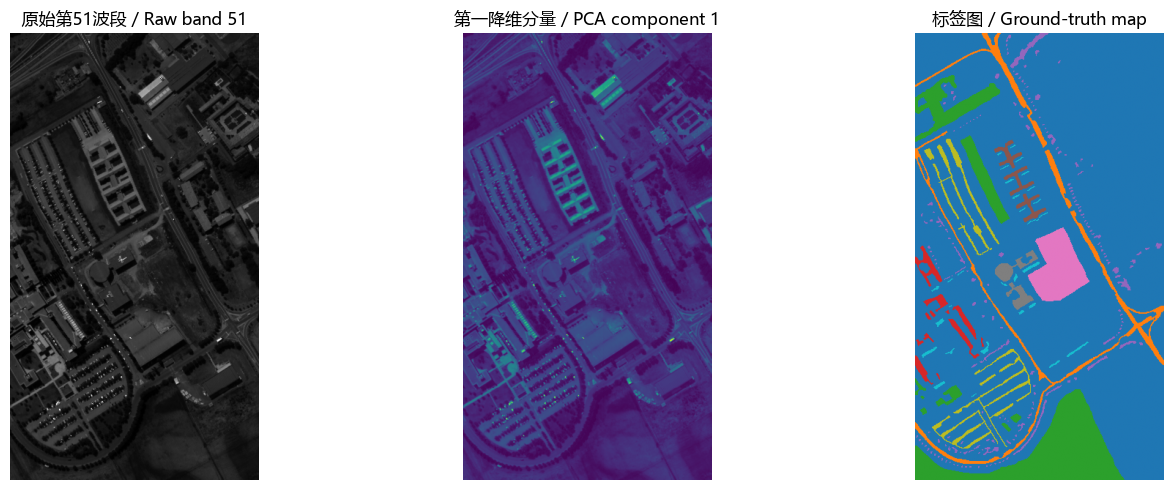

In [11]:
# 整体作用：并排预览原始波段、第一降维分量和标签图；这不是模型结果。
# Overall purpose: preview raw, transformed and label data; this is not a model result.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(data.cube[:, :, 50], cmap='gray')
axes[0].set_title('原始第51波段 / Raw band 51')
axes[1].imshow(transformed_cube[:, :, 0], cmap='viridis')
component_name = 'PCA' if config.reducer == 'pca' else 'LDA'
axes[1].set_title(f'第一降维分量 / {component_name} component 1')
axes[2].imshow(data.label_map, cmap='tab10', vmin=0, vmax=9)
axes[2].set_title('标签图 / Ground-truth map')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()


### 统计 4A：冻结降维解释比 / Analysis 4A: Frozen reducer ratios

PCA 显示训练方差保留比例；LDA 显示各判别方向的相对判别解释比。二者都不是分类准确率。


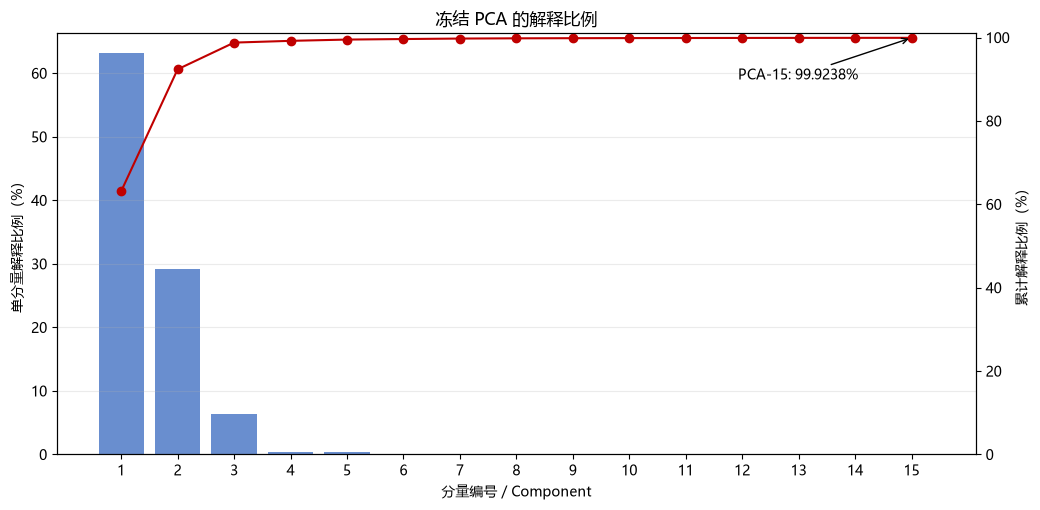

In [12]:
# 整体作用：展示 PCA/LDA 各分量解释比例，检查所保留的降维信息。

# 1. 从冻结 reducer 读取单分量解释比例并计算累计比例。
ratios = pipeline.reducer.explained_variance_ratio_ * 100
cumulative = np.cumsum(ratios)
components = np.arange(1, ratios.size + 1)

# 2. 柱形图表示单分量，折线表示累计解释比例。
reducer_ratio_figure, left_axis = plt.subplots(figsize=(10.5, 5.2))
right_axis = left_axis.twinx()
left_axis.bar(components, ratios, color='#4472C4', alpha=0.8)
right_axis.plot(components, cumulative, color='#C00000', marker='o')
left_axis.set_title(f'冻结 {config.reducer.upper()} 的解释比例')
left_axis.set_xlabel('分量编号 / Component')
left_axis.set_ylabel('单分量解释比例（%）')
right_axis.set_ylabel('累计解释比例（%）')
left_axis.set_xticks(components)
left_axis.grid(axis='y', alpha=0.25)
right_axis.set_ylim(0, 101)
right_axis.annotate(
    f'{config.reducer.upper()}-{ratios.size}: {cumulative[-1]:.4f}%',
    xy=(components[-1], cumulative[-1]), xytext=(-125, -30),
    textcoords='offset points', arrowprops={'arrowstyle': '->'},
)
reducer_ratio_figure.tight_layout()
plt.show()


### 统计 4B：训练集前两降维分量 / Analysis 4B: First two train-only components

每类最多固定抽取 500 个训练样本。PCA 观察最大方差方向，LDA 观察训练标签监督得到的判别方向；图中只使用训练样本。


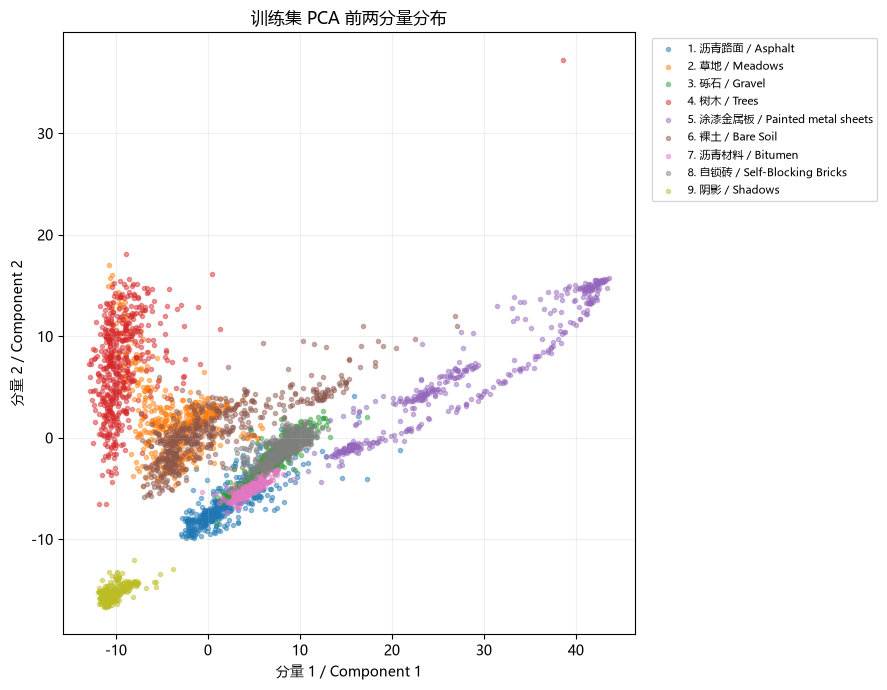

In [13]:
# 整体作用：只抽样训练集，观察前两个 PCA/LDA 分量中的类别分布。

# 1. 根据训练坐标读取前两个降维分量，验证/测试样本不参与绘图。
train_rows, train_columns = data.train_coordinates.T
features_2d = transformed_cube[train_rows, train_columns, :2]
train_labels = data.train_labels
generator = np.random.default_rng(1442)

# 2. 为避免大类遮挡，每类最多固定抽样 500 个点。
reducer_scatter_figure, axis = plt.subplots(figsize=(9, 7))
for class_id, english in enumerate(data.spec.class_names, start=1):
    positions = np.flatnonzero(train_labels == class_id)
    if positions.size > 500:
        positions = generator.choice(positions, size=500, replace=False)
    axis.scatter(
        features_2d[positions, 0], features_2d[positions, 1],
        s=9, alpha=0.45, color=CLASS_COLORS[class_id - 1],
        label=class_title(class_id, english),
    )
axis.set_title(f'训练集 {config.reducer.upper()} 前两分量分布')
axis.set_xlabel('分量 1 / Component 1')
axis.set_ylabel('分量 2 / Component 2')
axis.grid(alpha=0.2)
axis.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
reducer_scatter_figure.tight_layout()
plt.show()


### 统计 4C：冻结 PCA15 与 LDA8 分量对照 / Frozen PCA–LDA comparison

参考 Notebook 同时展示 PCA 和 LDA。本项目不在此处重新拟合，而是读取相同
`paper30/seed1442` 下已经冻结的 PCA15、LDA8 状态。二者都只由训练样本拟合，
测试集仅在正式模型冻结后用于一次最终评估。HybridSN baseline 固定使用 PCA15。


,方法,分量数,拟合样本,验证/测试参与拟合,baseline输入
0,PCA,15,12832,False,True
1,LDA,8,12832,False,False


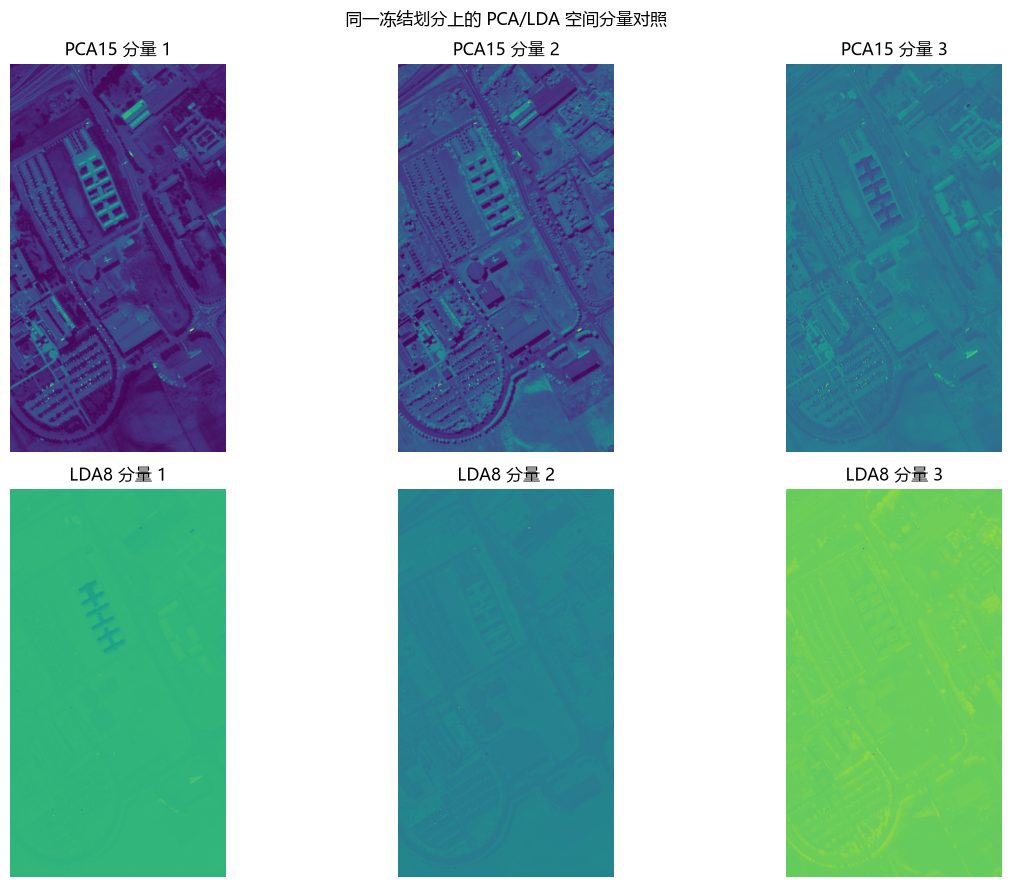

In [14]:
# 加载同一 split 上的冻结 LDA8，仅用于降维对照可视化，不改变 baseline 输入。
lda_state_dir = (
    PROJECT_ROOT / 'data/processed/pavia_university'
    / 'paper30__seed1442__standard_lda8_patch25'
)
lda_pipeline = HSIPreprocessingPipeline.load_state(
    lda_state_dir / 'preprocessing_state.npz',
    lda_state_dir / 'metadata.json',
)
assert lda_pipeline.fit_metadata_['fit_scope']['validation_and_test_used_for_fit'] is False
assert int(lda_pipeline.fit_metadata_['fit_scope']['training_samples']) == data.train_indices.size
lda_cube = lda_pipeline.attach_transformed_cube(data.cube)
assert lda_cube.shape == (610, 340, 8)

reducer_comparison_table = pd.DataFrame([
    {
        '方法': 'PCA', '分量数': transformed_cube.shape[-1],
        '拟合样本': int(pipeline.fit_metadata_['fit_scope']['training_samples']),
        '验证/测试参与拟合': False,
        'baseline输入': True,
    },
    {
        '方法': 'LDA', '分量数': lda_cube.shape[-1],
        '拟合样本': int(lda_pipeline.fit_metadata_['fit_scope']['training_samples']),
        '验证/测试参与拟合': False,
        'baseline输入': False,
    },
])
display(reducer_comparison_table)

reducer_comparison_figure, axes = plt.subplots(2, 3, figsize=(13, 9))
for row, (method, cube_for_display) in enumerate((('PCA15', transformed_cube), ('LDA8', lda_cube))):
    for component_index in range(3):
        axes[row, component_index].imshow(cube_for_display[:, :, component_index], cmap='viridis')
        axes[row, component_index].set_title(f'{method} 分量 {component_index + 1}')
        axes[row, component_index].axis('off')
reducer_comparison_figure.suptitle('同一冻结划分上的 PCA/LDA 空间分量对照')
reducer_comparison_figure.tight_layout()
reducer_comparison_figure.savefig(
    REPORT_ASSET_DIR / '06_PCA15与LDA8分量对照.png', dpi=220, bbox_inches='tight'
)
reducer_comparison_table.to_csv(
    REPORT_ASSET_DIR / '06_PCA15与LDA8口径对照.csv', index=False, encoding='utf-8-sig'
)
plt.show()


## 步骤 5：构造 Dataset / Step 5: Build datasets

- **目的 / Purpose：** 根据固定中心坐标按需提取 `25×25` 邻域。
- **输入 / Input：** 变换立方体、坐标、标签和 split 索引。
- **输出 / Output：** train/validation/test Dataset。
- **验收 / Acceptance：** 单样本输入为 `1×15×25×25`，身份字段互相对齐。


In [15]:
# 整体作用：构造 PyTorch Dataset，并检查单个训练样本的字段和 shape。

# 1. pipeline 使用已附加的变换后立方体，按固定索引建立三个 Dataset。
datasets = pipeline.build_torch_datasets(data)
for split_name in SPLIT_NAMES:
    dataset = datasets[split_name]
    actual = 0 if dataset is None else len(dataset)
    expected = int(data.indices_by_split[split_name].size)
    assert actual == expected

# 2. patch 不预先写入磁盘，而是在 __getitem__ 时围绕中心坐标动态提取。
sample = datasets['train'][0]
assert int(sample['raw_label']) == int(sample['label']) + 1
print({key: tuple(value.shape) for key, value in sample.items()})


{'input': (1, 15, 25, 25), 'label': (), 'raw_label': (), 'coordinate': (2,), 'sample_index': ()}


### 统计 5A：九类训练 patch 画廊 / Analysis 5A: Train patch gallery

每类选择一个靠近该类训练坐标中位位置的代表样本，显示第一主成分上的 25×25 邻域；红色加号是被分类的中心像元。


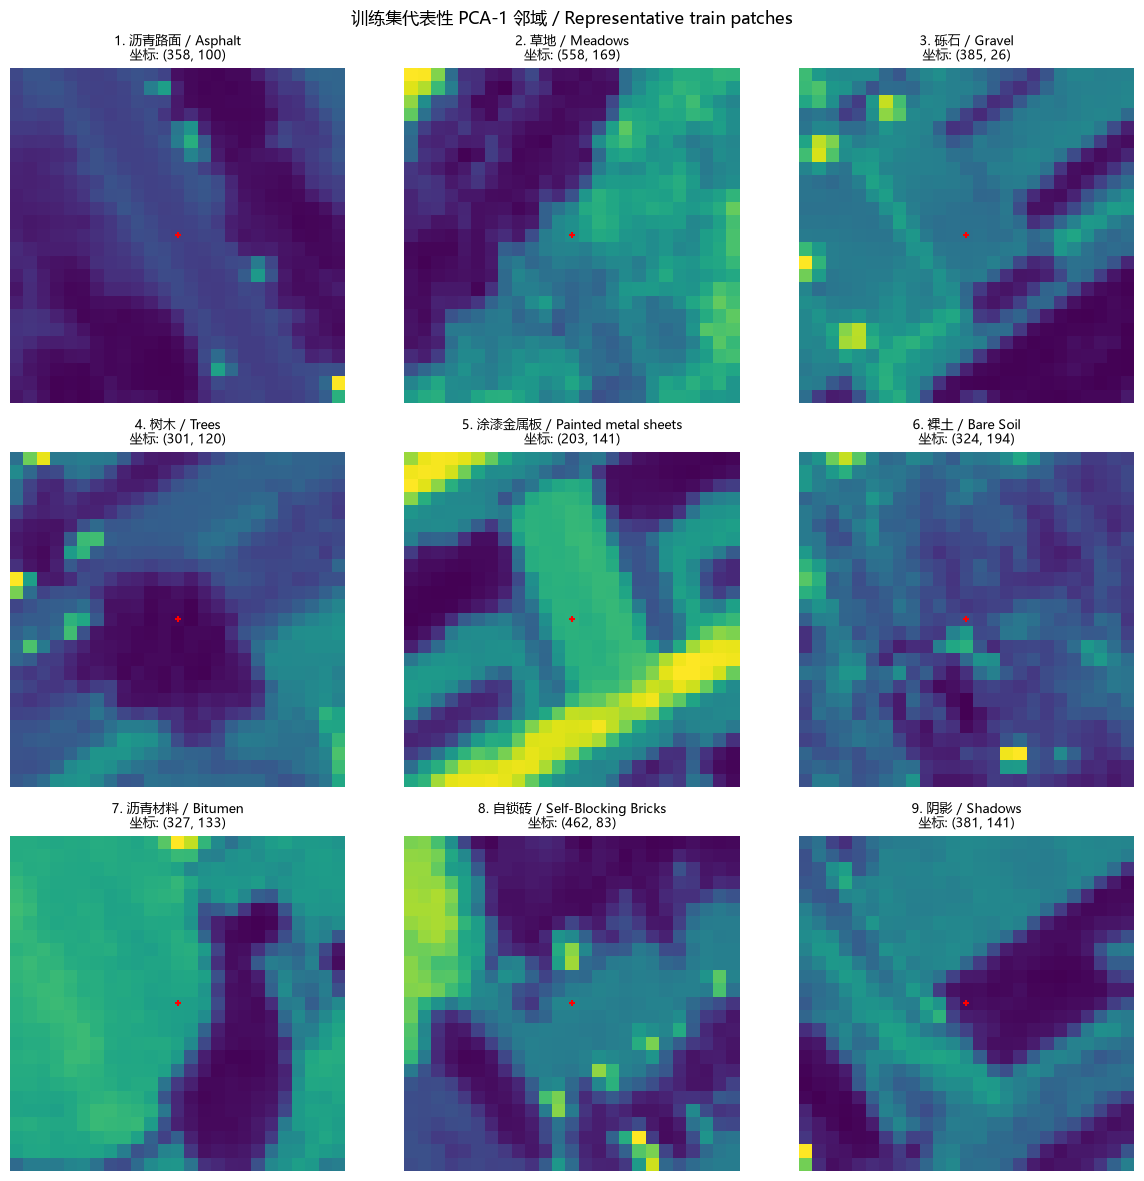

In [16]:
# 整体作用：按类别展示训练集代表性 patch，检查中心像元和空间邻域。

# 1. 对每一类选择距离该类训练坐标中位数最近的确定性代表样本。
train_dataset = datasets['train']
assert train_dataset is not None and train_dataset.representation == 'patch'
train_indices = train_dataset.sample_indices
labels_for_gallery = data.labels[train_indices]
coordinates_for_gallery = data.coordinates[train_indices]

# 2. 显示每个样本 patch 的第一 PCA 分量，并用红色十字标出中心像元。
patch_gallery_figure, axes = plt.subplots(3, 3, figsize=(12, 12))
for class_id, (english, axis) in enumerate(
    zip(data.spec.class_names, axes.reshape(-1)), start=1
):
    positions = np.flatnonzero(labels_for_gallery == class_id)
    class_coordinates = coordinates_for_gallery[positions]
    coordinate_median = np.median(class_coordinates, axis=0)
    representative = positions[
        np.argmin(np.square(class_coordinates - coordinate_median).sum(axis=1))
    ]
    patch_sample = train_dataset[int(representative)]
    patch = patch_sample['input'][0, 0].numpy()
    center = train_dataset.patch_size // 2
    axis.imshow(patch, cmap='viridis')
    axis.scatter([center], [center], c='red', s=18, marker='+')
    coordinate = tuple(int(value) for value in patch_sample['coordinate'])
    axis.set_title(class_title(class_id, english) + f'\n坐标: {coordinate}', fontsize=9)
    axis.axis('off')
patch_gallery_figure.suptitle('训练集代表性 PCA-1 邻域 / Representative train patches')
patch_gallery_figure.tight_layout()
plt.show()


## 步骤 6：构造 DataLoader / Step 6: Build dataloaders

- **目的 / Purpose：** 以可复现顺序组织批数据。
- **输入 / Input：** Dataset 和 YAML 中的 batch/seed/worker 参数。
- **输出 / Output：** 三个 DataLoader。
- **验收 / Acceptance：** `drop_last=False`，所有样本都能遍历。


In [17]:
# 整体作用：构造可复现的 DataLoader，并输出各 split 的 batch 数量。

# 训练集按 loader_seed 可复现打乱；验证/测试保持固定顺序且不丢弃尾批次。
loaders = pipeline.build_torch_loaders(
    data,
    batch_size=batch_size,
    loader_seed=loader_seed,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
for split_name in SPLIT_NAMES:
    sample_count = int(data.indices_by_split[split_name].size)
    expected_batches = math.ceil(sample_count / batch_size) if sample_count else 0
    actual_batches = 0 if loaders[split_name] is None else len(loaders[split_name])
    assert actual_batches == expected_batches
print({name: None if loader is None else len(loader) for name, loader in loaders.items()})


{'train': 51, 'validation': None, 'test': 117}


## 步骤 7：检查模型输入批次 / Step 7: Inspect a model-input batch

- **目的 / Purpose：** 在模型开发前固定公开的数据接口。
- **输入 / Input：** train DataLoader 第一个 batch。
- **输出 / Output：** `input/label/raw_label/coordinate/sample_index`。
- **验收 / Acceptance：** 输入为 `N×1×15×25×25`；模型标签为 0–8，原标签为 1–9。


In [18]:
# 整体作用：验收首个训练 batch，确认未来模型使用的 input/label 接口。

# 1. 从训练 DataLoader 取一个 batch，并检查必须存在的身份字段。
batch = next(iter(loaders['train']))
required_keys = {'input', 'label', 'raw_label', 'coordinate', 'sample_index'}
assert set(batch) == required_keys

# 2. 核对 HybridSN 输入、dtype、标签映射和数值有限性。
inputs = batch['input']
expected_tail = (1, config.n_components, config.patch_size, config.patch_size)
assert inputs.ndim == 5 and tuple(inputs.shape[1:]) == expected_tail
assert inputs.dtype == torch.float32
assert batch['label'].dtype == torch.int64
assert torch.equal(batch['raw_label'], batch['label'] + 1)
assert torch.isfinite(inputs).all()
print({key: tuple(value.shape) for key, value in batch.items()})

# 3. 模型训练只消费 input 和 label；其余字段用于预测追溯和分类图回填。
print('模型以后只需要读取 batch[\"input\"] 和 batch[\"label\"]')
print('Future models only need batch[\"input\"] and batch[\"label\"]')


{'input': (256, 1, 15, 25, 25), 'label': (256,), 'raw_label': (256,), 'coordinate': (256, 2), 'sample_index': (256,)}
模型以后只需要读取 batch["input"] 和 batch["label"]
Future models only need batch["input"] and batch["label"]


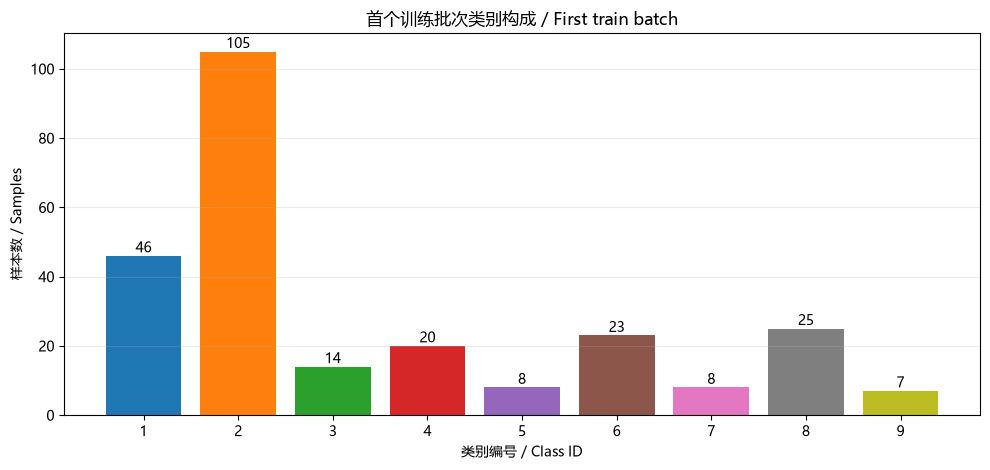

In [19]:
# 整体作用：绘制首个训练 batch 的类别构成，观察随机打乱后的批次分布。

batch_labels = batch['label'].cpu().numpy()
batch_class_counts = np.bincount(batch_labels, minlength=len(data.spec.class_names))
class_ids = np.arange(1, len(data.spec.class_names) + 1)

batch_distribution_figure, axis = plt.subplots(figsize=(10, 4.8))
bars = axis.bar(class_ids, batch_class_counts, color=CLASS_COLORS)
axis.set_title('首个训练批次类别构成 / First train batch')
axis.set_xlabel('类别编号 / Class ID')
axis.set_ylabel('样本数 / Samples')
axis.set_xticks(class_ids)
axis.grid(axis='y', alpha=0.25)
for bar, count in zip(bars, batch_class_counts):
    axis.text(
        bar.get_x() + bar.get_width() / 2, count, str(int(count)),
        ha='center', va='bottom',
    )
batch_distribution_figure.tight_layout()
plt.show()


## 步骤 8：保存模型就绪数据集 / Step 8: Save the model-ready dataset

- **目的 / Purpose：** 让模型 Notebook 不再重复读取原始 MAT 或执行 PCA，只加载冻结结果。
- **输入 / Input：** 训练集专用标准化与 PCA15 得到的 `610×340×15` 立方体、固定坐标、标签和 split 索引。
- **输出 / Output：** 当前冻结状态目录下的 `model_ready_dataset.npz`。
- **原理 / Principle：** 保存一次变换立方体，训练时仍按坐标动态提取 patch25，避免物化约 1.5 GiB 的重复邻域。
- **验收 / Acceptance：** `paper30`、seed=1442、PCA15、float32、12,832/0/29,944，且已有文件绝不覆盖。


In [20]:
# 整体作用：保存供模型 Notebook 只读使用的数据产物；已存在时只核验并复用。

# 定义产物路径并计算三个 split 的实际样本数 / Define path and split counts
MODEL_READY_PATH = state_dir / 'model_ready_dataset.npz'
expected_counts = {'train': 12832, 'validation': 0, 'test': 29944}
actual_counts = {name: int(indices.size) for name, indices in data.indices_by_split.items()}

# 保存前强制核对论文基线协议、预处理、shape、dtype 和样本数 / Enforce invariants
assert config.split_protocol == 'paper30'
assert config.split_seed == 1442
assert config.standardization == 'standard'
assert config.reducer == 'pca'
assert config.n_components == 15
assert config.whiten is False
assert config.representation == 'patch'
assert config.patch_size == 25
assert transformed_cube.shape == (610, 340, 15)
assert transformed_cube.dtype == np.float32
assert actual_counts == expected_counts

# 已存在则核验指纹和元数据，禁止静默覆盖；否则首次创建 / Verify or create once
if MODEL_READY_PATH.exists():
    with np.load(MODEL_READY_PATH, allow_pickle=False) as saved:
        assert str(saved['config_fingerprint'].item()) == config.fingerprint()
        assert tuple(saved['transformed_cube'].shape) == (610, 340, 15)
        assert str(saved['split_protocol'].item()) == 'paper30'
        assert int(saved['split_seed'].item()) == 1442
    print(f'已核验并复用 / Verified and reused: {MODEL_READY_PATH}')
else:
    np.savez_compressed(
        MODEL_READY_PATH,
        schema_version=np.asarray('1.0'),
        dataset_name=np.asarray(config.dataset_name),
        split_protocol=np.asarray(config.split_protocol),
        split_seed=np.asarray(config.split_seed, dtype=np.int64),
        config_fingerprint=np.asarray(config.fingerprint()),
        transformed_cube=np.ascontiguousarray(transformed_cube, dtype=np.float32),
        coordinates=np.ascontiguousarray(data.coordinates, dtype=np.int32),
        raw_labels=np.ascontiguousarray(data.labels, dtype=np.int16),
        train_indices=np.ascontiguousarray(data.indices_by_split['train'], dtype=np.int64),
        validation_indices=np.ascontiguousarray(data.indices_by_split['validation'], dtype=np.int64),
        test_indices=np.ascontiguousarray(data.indices_by_split['test'], dtype=np.int64),
        class_names=np.asarray(data.spec.class_names),
        patch_size=np.asarray(config.patch_size, dtype=np.int64),
        padding_mode=np.asarray(config.padding_mode),
        padding_value=np.asarray(config.padding_value, dtype=np.float32),
        num_classes=np.asarray(len(data.spec.class_names), dtype=np.int64),
    )
    print(f'已保存 / Saved: {MODEL_READY_PATH}')

# 输出产物大小，便于检查磁盘占用 / Report artifact size
print(f'文件大小 / File size: {MODEL_READY_PATH.stat().st_size / 1024**2:.2f} MiB')


已核验并复用 / Verified and reused: G:\高光谱智能图像解译\实验交付\data\processed\pavia_university\paper30__seed1442__standard_pca15_patch25\model_ready_dataset.npz
文件大小 / File size: 11.36 MiB


## 步骤 9：集中导出实验报告素材 / Export report-ready artifacts

除 Notebook 内嵌输出外，本节把关键图表以 220 dpi PNG、统计表以 UTF-8-BOM CSV
写入固定目录。这样后续在 Word 中插图时无需截图，也不会引用临时运行目录。


In [21]:
# 将前面已经验收过的 Figure 对象集中导出，文件名按报告叙事顺序编号。
figures_to_export = {
    '02_固定划分数量.png': split_count_figure,
    '02_固定划分空间分布.png': split_map_figure,
    '04_训练集逐类光谱.png': spectral_figure,
    '05_降维解释比例.png': reducer_ratio_figure,
    '05_训练集前两分量分布.png': reducer_scatter_figure,
    '07_九类代表性Patch.png': patch_gallery_figure,
    '08_首个训练批次类别分布.png': batch_distribution_figure,
}
for filename, figure in figures_to_export.items():
    figure.savefig(REPORT_ASSET_DIR / filename, dpi=220, bbox_inches='tight')

split_rows = []
for class_id, english_name in enumerate(data.spec.class_names, start=1):
    row = {
        '类别编号': class_id,
        '中文类别': PAVIA_CLASS_NAMES_ZH[class_id - 1],
        'English class': english_name,
    }
    for split_column, split_name in enumerate(SPLIT_NAMES):
        row[split_name] = int(counts[class_id - 1, split_column])
    row['total'] = int(counts[class_id - 1].sum())
    split_rows.append(row)
split_table = pd.DataFrame(split_rows)
split_table.to_csv(REPORT_ASSET_DIR / '02_逐类划分数量.csv', index=False, encoding='utf-8-sig')

preprocessing_summary = pd.DataFrame([
    {'环节': '原始数据', '结果': str(tuple(data.cube.shape)), '约束': 'PaviaU, 103 bands'},
    {'环节': '固定划分', '结果': 'train=12,832; validation=0; test=29,944', '约束': 'paper30, seed=1442'},
    {'环节': '标准化+PCA', '结果': str(tuple(transformed_cube.shape)), '约束': '仅训练集拟合; PCA15; no whiten'},
    {'环节': '模型输入', '结果': '(N, 1, 15, 25, 25)', '约束': '动态 patch; constant padding'},
    {'环节': '模型就绪产物', '结果': str(MODEL_READY_PATH.relative_to(PROJECT_ROOT)), '约束': config.fingerprint()},
])
preprocessing_summary.to_csv(
    REPORT_ASSET_DIR / '00_预处理流程摘要.csv', index=False, encoding='utf-8-sig'
)
display(preprocessing_summary)
print('已导出 / Exported:')
for path in sorted(REPORT_ASSET_DIR.iterdir()):
    print(f'  - {path.relative_to(PROJECT_ROOT)}')


,环节,结果,约束
0,原始数据,"(610, 340, 103)","PaviaU, 103 bands"
1,固定划分,"train=12,832; validation=0; test=29,944","paper30, seed=1442"
2,标准化+PCA,"(610, 340, 15)",仅训练集拟合; PCA15; no whiten
3,模型输入,"(N, 1, 15, 25, 25)",动态 patch; constant padding
4,模型就绪产物,data\processed\pavia_university\paper30__seed1...,884942048935b51bf385e1d6c124eee59ea96bb04ac147...


已导出 / Exported:
  - results\notebook_outputs\reference_aligned\data_preprocessing\00_预处理流程摘要.csv
  - results\notebook_outputs\reference_aligned\data_preprocessing\01_PaviaU数据总览.png
  - results\notebook_outputs\reference_aligned\data_preprocessing\01_PaviaU类别数量.csv
  - results\notebook_outputs\reference_aligned\data_preprocessing\02_固定划分数量.png
  - results\notebook_outputs\reference_aligned\data_preprocessing\02_固定划分空间分布.png
  - results\notebook_outputs\reference_aligned\data_preprocessing\02_逐类划分数量.csv
  - results\notebook_outputs\reference_aligned\data_preprocessing\03_训练集波段相关矩阵.png
  - results\notebook_outputs\reference_aligned\data_preprocessing\04_训练集逐类光谱.png
  - results\notebook_outputs\reference_aligned\data_preprocessing\05_训练集前两分量分布.png
  - results\notebook_outputs\reference_aligned\data_preprocessing\05_降维解释比例.png
  - results\notebook_outputs\reference_aligned\data_preprocessing\06_PCA15与LDA8分量对照.png
  - results\notebook_outputs\reference_aligned\data_preprocessing\06_PCA15与LDA

## 如何阅读这些统计图 / How to interpret the visual statistics

1. **类别不均衡 / Class imbalance：** Meadows 的样本明显多于 Shadows、Painted metal sheets 等类别。后续不能只看 OA，还应报告 AA、逐类准确率和混淆矩阵。是否使用类别权重必须在验证集上决定。
2. **光谱差异 / Spectral differences：** 观察九类训练均值曲线在哪些波段分离，以及标准差范围是否大量重叠。这只能形成波段选择假设，不能直接证明分类效果。
3. **降维解释比 / Reducer ratios：** PCA 方差比与 LDA 判别解释比含义不同；二者都不等于准确率。
4. **降维散点 / Reducer scatter：** PCA 不使用标签，LDA 只用训练标签；二维投影不能替代正式分类评价。
5. **空间邻域 / Spatial patches：** 比较不同类别的形状、纹理和边界。红色中心是当前标签归属像元，邻域内其他像元的标签没有被用于输入。
6. **batch 构成 / Batch composition：** 首个 batch 是训练集随机打乱后的一个样本，不会严格保持 24%/6%/70% 或逐类均衡，也不能代表整个训练集。
7. **安全边界 / Safety boundary：** split 数量和位置可展示全部划分；特征内容分析只使用训练集。测试集特征、预测和指标应留到最终配置冻结以后。

---

## 本阶段输出 / Output of this stage

现在已经得到后续模型可以共享的公开接口：

```python
inputs = batch['input']   # N×1×B×25×25, float32；PCA15: B=15，LDA8: B=8
labels = batch['label']   # N, int64, values 0..8
```

`raw_label`、`coordinate` 和 `sample_index` 用于结果追溯和分类图回填。模型 Notebook 只读取 `model_ready_dataset.npz`；核心模型定义仍以 `src/models/HybridSN模型.py` 为唯一实现，避免在 Notebook 中复制出第二套网络。
